In [3]:
import interp

m = interp.load("gpt2-small")
cap = interp.run(m, "The cat sat on the")

print("prompt:", cap.prompt)

print("tokens:", cap.tokens)
print("attn:  ", cap.attn.shape, "[n_layers, n_heads, seq, seq]")
print("logits:", cap.logits.shape, "[seq, vocab]")

# a single head's [seq, seq] attention matrix, ready to imshow
print("attn[0, 0]:\n", cap.attn[0, 0])

# any other activation as numpy
print("resid_post layer 6:", interp.act(cap, "resid_post", 6).shape)
print("mlp_out layer 3:   ", interp.act(cap, "mlp_out", 3).shape)


/Users/nshelton/c3p0/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11045.50it/s]


Loaded pretrained model gpt2-small into HookedTransformer
prompt: The cat sat on the
tokens: ['<|endoftext|>', 'The', ' cat', ' sat', ' on', ' the']
attn:   (12, 12, 6, 6) [n_layers, n_heads, seq, seq]
logits: (6, 50257) [seq, vocab]
attn[0, 0]:
 [[1.         0.         0.         0.         0.         0.        ]
 [0.93303794 0.06696212 0.         0.         0.         0.        ]
 [0.7137718  0.10261495 0.1836133  0.         0.         0.        ]
 [0.63771695 0.14318715 0.04401174 0.1750841  0.         0.        ]
 [0.48095414 0.14646298 0.11887706 0.22755365 0.02615208 0.        ]
 [0.5961567  0.11626384 0.08882766 0.15676554 0.0184834  0.02350275]]
resid_post layer 6: (6, 768)
mlp_out layer 3:    (6, 768)


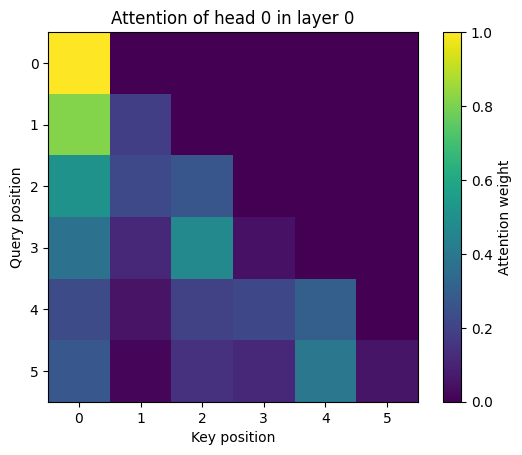

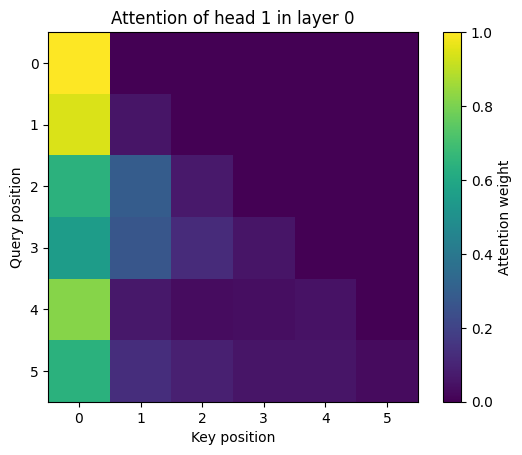

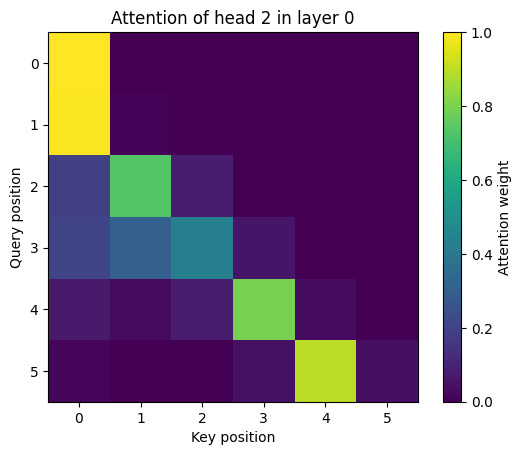

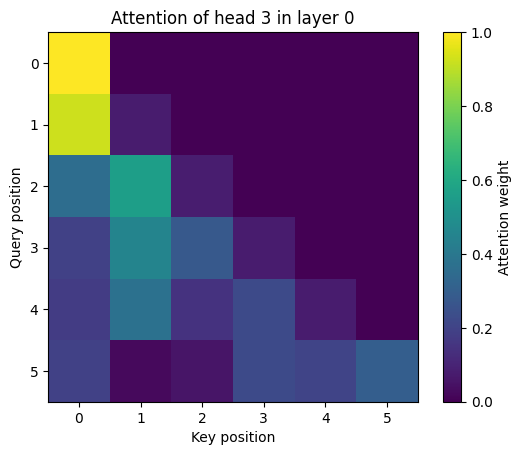

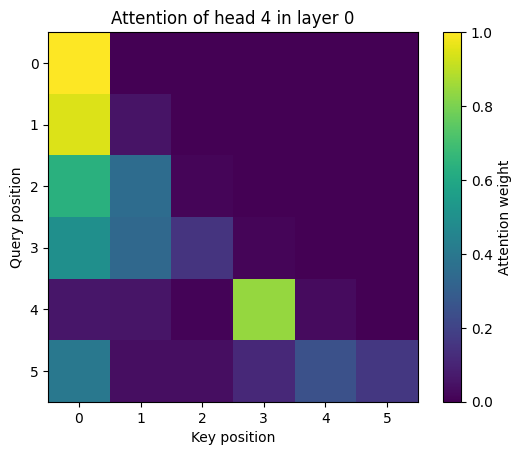

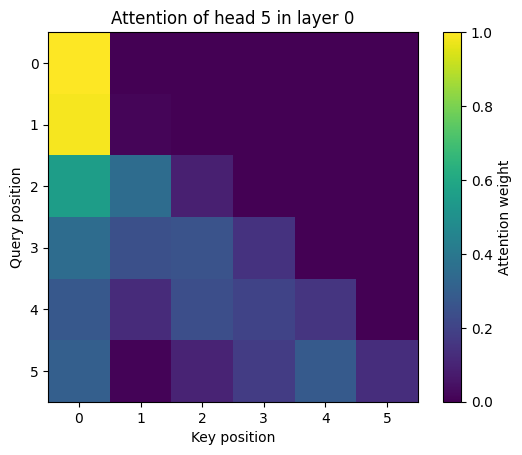

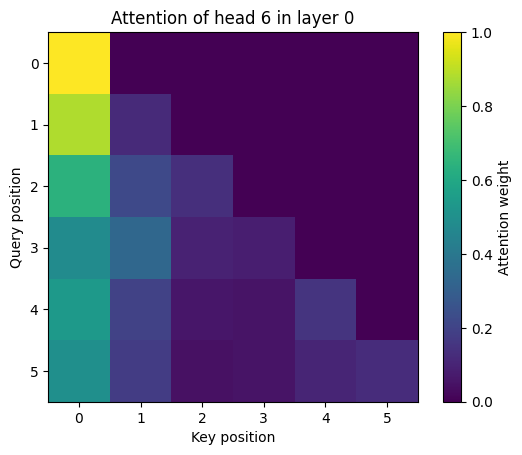

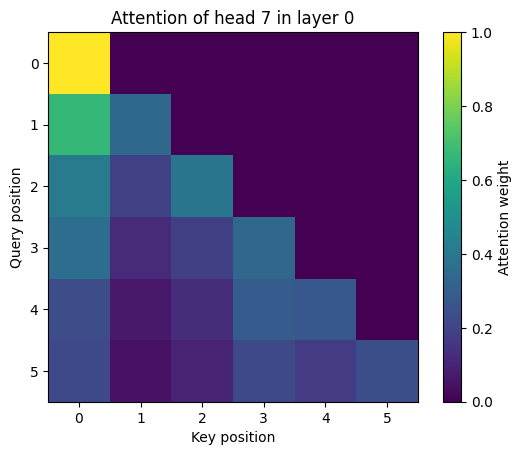

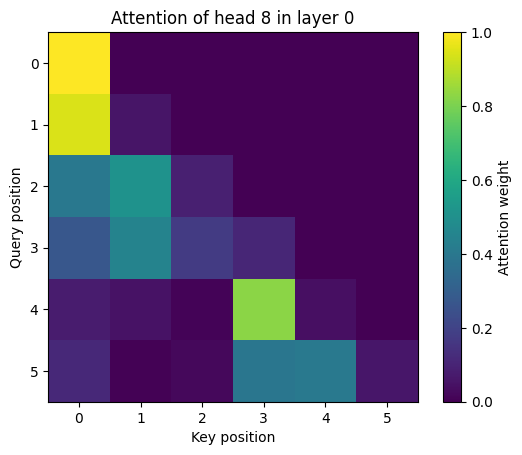

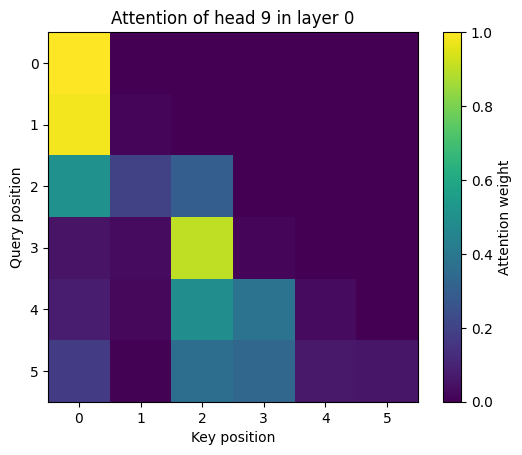

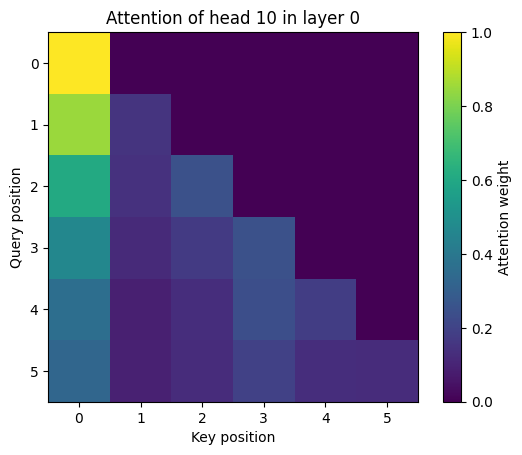

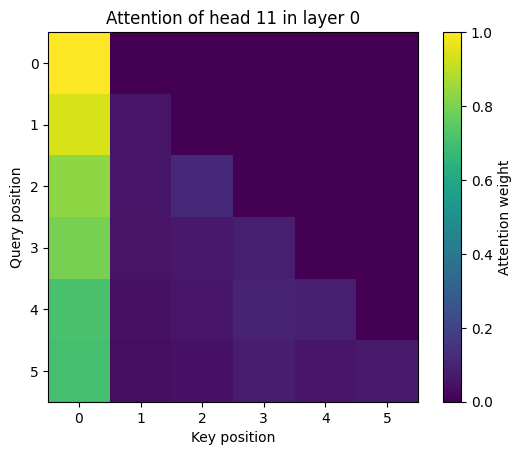

In [9]:
import matplotlib.pyplot as plt

for i in range(12):
    plt.imshow(cap.attn[2, i])
    plt.title(f"Attention of head {i} in layer 0")
    plt.xlabel("Key position")
    plt.ylabel("Query position")

    plt.colorbar(label="Attention weight")
    plt.show()

In [8]:
cap.attn.shape

(12, 12, 6, 6)

In [2]:
! pip install matplotlib